# MODELLING

## Import the necessary libraries

In [ ]:

# Data manipulation


import numpy as np
import pandas as pd


# File handling


from pathlib import Path

# Regular expressions


import re


# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Warnings


import warnings

warnings.filterwarnings("ignore")


# Scikit-learn: Data splitting and cross-validation


from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)


# Scikit-learn: Preprocessing


from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline


# Scikit-learn: Models


from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier


# Gradient Boosting Models


from xgboost import XGBClassifier

from lightgbm import LGBMClassifier


# Imbalanced-learn


from imblearn.pipeline import Pipeline as ImbPipeline

from imblearn.over_sampling import SMOTE

# Evaluation metrics


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss
)


# Calibration


from sklearn.calibration import calibration_curve


# Model interpretation


import shap

# Model saving


import pickle

from datetime import datetime


# Display options


pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_rows",
    100
)

## 1. Load the data set after the feature engineering

In [2]:
# Define the output folder
OUTPUT_DIR = Path("./output")
train = pd.read_parquet(
    OUTPUT_DIR / "train_feature_engineered.parquet"
)

test = pd.read_parquet(
    OUTPUT_DIR / "test_feature_engineered.parquet"
)

print(train.shape)
print(test.shape)

(307511, 702)
(48744, 701)


## 2. Inspect the loaded data

In [3]:
# View dataset information
print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (307511, 702)
Test shape: (48744, 701)


,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_SUM,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_MAX,BUREAU_CREDIT_DAY_OVERDUE_MEAN,BUREAU_CREDIT_DAY_OVERDUE_SUM,BUREAU_CREDIT_DAY_OVERDUE_MIN,BUREAU_CREDIT_DAY_OVERDUE_MAX,BUREAU_DAYS_CREDIT_ENDDATE_MEAN,BUREAU_DAYS_CREDIT_ENDDATE_SUM,BUREAU_DAYS_CREDIT_ENDDATE_MIN,BUREAU_DAYS_CREDIT_ENDDATE_MAX,BUREAU_DAYS_ENDDATE_FACT_MEAN,BUREAU_DAYS_ENDDATE_FACT_SUM,BUREAU_DAYS_ENDDATE_FACT_MIN,BUREAU_DAYS_ENDDATE_FACT_MAX,BUREAU_AMT_CREDIT_MAX_OVERDUE_MEAN,BUREAU_AMT_CREDIT_MAX_OVERDUE_SUM,BUREAU_AMT_CREDIT_MAX_OVERDUE_MIN,BUREAU_AMT_CREDIT_MAX_OVERDUE_MAX,BUREAU_CNT_CREDIT_PROLONG_MEAN,BUREAU_CNT_CREDIT_PROLONG_SUM,BUREAU_CNT_CREDIT_PROLONG_MIN,BUREAU_CNT_CREDIT_PROLONG_MAX,BUREAU_AMT_CREDIT_SUM_MEAN,BUREAU_AMT_CREDIT_SUM_SUM,BUREAU_AMT_CREDIT_SUM_MIN,BUREAU_AMT_CREDIT_SUM_MAX,BUREAU_AMT_CREDIT_SUM_DEBT_MEAN,BUREAU_AMT_CREDIT_SUM_DEBT_SUM,BUREAU_AMT_CREDIT_SUM_DEBT_MIN,BUREAU_AMT_CREDIT_SUM_DEBT_MAX,BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN,BUREAU_AMT_CREDIT_SUM_LIMIT_SUM,BUREAU_AMT_CREDIT_SUM_LIMIT_MIN,BUREAU_AMT_CREDIT_SUM_LIMIT_MAX,BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN,BUREAU_AMT_CREDIT_SUM_OVERDUE_SUM,BUREAU_AMT_CREDIT_SUM_OVERDUE_MIN,BUREAU_AMT_CREDIT_SUM_OVERDUE_MAX,BUREAU_DAYS_CREDIT_UPDATE_MEAN,BUREAU_DAYS_CREDIT_UPDATE_SUM,BUREAU_DAYS_CREDIT_UPDATE_MIN,BUREAU_DAYS_CREDIT_UPDATE_MAX,BUREAU_AMT_ANNUITY_MEAN,BUREAU_AMT_ANNUITY_SUM,BUREAU_AMT_ANNUITY_MIN,BUREAU_AMT_ANNUITY_MAX,BUREAU_BB_MONTHS_COUNT_MEAN,BUREAU_BB_MONTHS_COUNT_SUM,BUREAU_BB_MONTHS_COUNT_MIN,BUREAU_BB_MONTHS_COUNT_MAX,BUREAU_BB_MONTHS_MIN_MEAN,BUREAU_BB_MONTHS_MIN_SUM,BUREAU_BB_MONTHS_MIN_MIN,BUREAU_BB_MONTHS_MIN_MAX,BUREAU_BB_MONTHS_MAX_MEAN,BUREAU_BB_MONTHS_MAX_SUM,BUREAU_BB_MONTHS_MAX_MIN,BUREAU_BB_MONTHS_MAX_MAX,BUREAU_BB_STATUS_0_MEAN,BUREAU_BB_STATUS_0_SUM,BUREAU_BB_STATUS_0_MIN,BUREAU_BB_S

## 3. Check data types

In [4]:
# Check feature types
numeric_cols = train.select_dtypes(include="number").columns.tolist()

categorical_cols = train.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

categorical_cols

Numeric columns: 686
Categorical columns: 16


['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

## 4. Separate the target and IDs

In [5]:
# Target variable
y = train["TARGET"]

# IDs
train_ids = train["SK_ID_CURR"]
test_ids = test["SK_ID_CURR"]

# Feature matrices
X = train.drop(columns=["TARGET", "SK_ID_CURR"])
X_test = test.drop(columns=["SK_ID_CURR"])

print(X.shape)
print(X_test.shape)

(307511, 700)
(48744, 700)


## 5. Identify categorical columns

In [6]:
categorical_cols = X.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print(f"Categorical columns: {len(categorical_cols)}")
categorical_cols

Categorical columns: 16


['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

## 6. Encoding

#### Step 1: Cardinality check

Check the number of unique categories of each categorical feature. This will help in identfying what type of encoding should I consider

In [7]:
# Check the number of unique values in each categorical feature

cardinality = (
    X[categorical_cols]
    .nunique()
    .sort_values(ascending=False)
    .to_frame(name="Unique Categories")
)

display(cardinality)

,Unique Categories
ORGANIZATION_TYPE,58
OCCUPATION_TYPE,19
NAME_INCOME_TYPE,8
NAME_TYPE_SUITE,8
WALLSMATERIAL_MODE,8
WEEKDAY_APPR_PROCESS_START,7
NAME_FAMILY_STATUS,6
NAME_HOUSING_TYPE,6
NAME_EDUCATION_TYPE,5
FONDKAPREMONT_MODE,5


### Cardinality Analysis

Cardinality analysis was performed to determine the number of unique categories in each categorical feature before choosing an encoding method. Most categorical variables had a small number of unique categories, ranging from 2 to 19. For example, `NAME_CONTRACT_TYPE`, `FLAG_OWN_CAR`, and `FLAG_OWN_REALTY` had only 2 unique categories, while `OCCUPATION_TYPE` had 19 categories.

The feature with the highest cardinality was `ORGANIZATION_TYPE`, which contained 58 unique categories. To reduce the number of dummy variables created during encoding and improve model efficiency, only the 15 most frequent organization types will be retained, while the remaining less frequent categories will be grouped into a single category labelled **"Other"**.

Overall, the dataset contains mostly low-cardinality categorical variables. Therefore, One-Hot Encoding is an appropriate encoding technique. Grouping the rare `ORGANIZATION_TYPE` categories before encoding helps reduce dimensionality while preserving the most important information in the data.

In [8]:
# Check categories for the two highest-cardinality features

for col in ["ORGANIZATION_TYPE"]:
    print("=" * 60)
    print(f"{col}")
    print("=" * 60)

    print(f"Number of unique categories: {X[col].nunique()}\n")

    display(
        X[col]
        .value_counts(dropna=False)
        .to_frame(name="Count")
    )

ORGANIZATION_TYPE
Number of unique categories: 58



,Count
ORGANIZATION_TYPE,
Business Entity Type 3,67992
XNA,55374
Self-employed,38412
Other,16683
Medicine,11193
Business Entity Type 2,10553
Government,10404
School,8893
Trade: type 7,7831


##### Step 2: Reduce cardinality of ORGANIZATION_TYPE

In [9]:
# Keep the top 15 categories
top_15_org = (
    X["ORGANIZATION_TYPE"]
    .value_counts()
    .nlargest(15)
    .index
)

# Group the rest into "Other"
for df in [X, X_test]:
    df["ORGANIZATION_TYPE"] = np.where(
        df["ORGANIZATION_TYPE"].isin(top_15_org),
        df["ORGANIZATION_TYPE"],
        "Other"
    )

print(X["ORGANIZATION_TYPE"].nunique())
print(X["ORGANIZATION_TYPE"].value_counts())

15
ORGANIZATION_TYPE
Business Entity Type 3    67992
Other                     65016
XNA                       55374
Self-employed             38412
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Name: count, dtype: int64


In [10]:
print("Training set:")
print(X["ORGANIZATION_TYPE"].nunique())

print("\nTest set:")
print(X_test["ORGANIZATION_TYPE"].nunique())

Training set:
15

Test set:
15


## 7. Encode categorical features and scale numeric features

In [11]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=False,
    dtype="int8"
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=False,
    dtype="int8"
)

X, X_test = X.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

##### Aligning train and test

In [12]:
# Ensure train and test have identical columns

X, X_test = X.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

#### Verify the encoding

In [13]:
# Recompute feature types

numeric_cols = X.select_dtypes(include="number").columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

Numeric columns: 787
Categorical columns: 0


#### Clean the column names

In [14]:


def clean_column_names(df):
    df = df.copy()

    df.columns = [
        re.sub(r'[^A-Za-z0-9_]', '_', col)
        for col in df.columns
    ]

    return df

In [15]:
X = clean_column_names(X)
X_test = clean_column_names(X_test)

## 8. Train / validation split

##### Splitting  the data

In [16]:


# Split into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Validation features:", X_valid.shape)
print("Training target:", y_train.shape)
print("Validation target:", y_valid.shape)

Training features: (246008, 787)
Validation features: (61503, 787)
Training target: (246008,)
Validation target: (61503,)


##### Verify the class distribution

This confirms that stratification worked correctly.

In [17]:
print("Original target distribution:")
print(y.value_counts(normalize=True))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_valid.value_counts(normalize=True))

Original target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Training target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Validation target distribution:
TARGET
0    0.919272
1    0.080728
Name: proportion, dtype: float64


## 9. Handle class imbalance with SMOTE

In [18]:

# Handle Class Imbalance using SMOTE


smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_smote.value_counts())

Before SMOTE
TARGET
0    226148
1     19860
Name: count, dtype: int64

After SMOTE
TARGET
0    226148
1    226148
Name: count, dtype: int64


In [19]:
print("Duplicate columns:", X.columns.duplicated().sum())

Duplicate columns: 0


To address the class imbalance in the training data, the Synthetic Minority Oversampling Technique (SMOTE) was applied after splitting the dataset into training and validation sets. This ensured that only the training data was balanced, preventing data leakage into the validation set.

## 10. Scale the Data (Logistic Regression Only)

In [20]:

# Feature Scaling

scaler = StandardScaler()

# Logistic Regression
X_train_scaled = scaler.fit_transform(X_train_smote)

X_valid_scaled = scaler.transform(X_valid)

X_test_scaled = scaler.transform(X_test) 

## 11. Create an Evaluation Function
To avoid writing the same evaluation code for every model.

In [21]:

# Model Evaluation Function


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

def evaluate_model(model_name, y_true, y_pred, y_prob):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    })

## 12. Train the Baseline Models


#### 1. Logistic Regression

In [22]:

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)
log_model.fit(X_train_scaled, y_train_smote)

log_pred = log_model.predict(X_valid_scaled)

log_prob = log_model.predict_proba(X_valid_scaled)[:, 1]

evaluate_model(
    "Logistic Regression",
    y_valid,
    log_pred,
    log_prob
)

Logistic Regression was trained using the scaled SMOTE-balanced training data because it is sensitive to feature magnitudes.

#### 2. Decision Tree

In [23]:


dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train_smote, y_train_smote)

dt_pred = dt_model.predict(X_valid)

dt_prob = dt_model.predict_proba(X_valid)[:,1]

evaluate_model(
    "Decision Tree",
    y_valid,
    dt_pred,
    dt_prob
)

#### 3. Random Forest

In [24]:


rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

rf_pred = rf_model.predict(X_valid)

rf_prob = rf_model.predict_proba(X_valid)[:,1]

evaluate_model(
    "Random Forest",
    y_valid,
    rf_pred,
    rf_prob
)

#### 4. XGBoost

In [25]:


xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_smote, y_train_smote)

xgb_pred = xgb_model.predict(X_valid)

xgb_prob = xgb_model.predict_proba(X_valid)[:,1]

evaluate_model(
    "XGBoost",
    y_valid,
    xgb_pred,
    xgb_prob
)

#### 5. LightGBM

In [26]:
# Train the original LightGBM model

lgbm_model = LGBMClassifier(
    random_state=42
)

lgbm_model.fit(
    X_train_smote,
    y_train_smote
)
# Generate LightGBM predictions

lgbm_pred = lgbm_model.predict(X_valid)

lgbm_prob = lgbm_model.predict_proba(
    X_valid
)[:, 1]

# Evaluate LightGBM

evaluate_model(
    "LightGBM",
    y_valid,
    lgbm_pred,
    lgbm_prob
)

[LightGBM] [Info] Number of positive: 226148, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.711657 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 133760
[LightGBM] [Info] Number of data points in the train set: 452296, number of used features: 772
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


Decision Tree, Random Forest, XGBoost, and LightGBM were trained using the SMOTE-balanced training data without feature scaling, as tree-based algorithms are generally not affected by differences in feature scale.

#### Compare the Models

In [27]:
results_df = (
    pd.DataFrame(results)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,LightGBM,0.919695,0.565000,0.022759,0.043756,0.779973
1,Logistic Regression,0.919760,0.546296,0.035650,0.066931,0.776599
2,XGBoost,0.918801,0.477165,0.061027,0.108214,0.773136
3,Random Forest,0.919288,0.514286,0.003625,0.007200,0.735794
4,Decision Tree,0.844739,0.142879,0.184693,0.161117,0.543698


The baseline model comparison shows that LightGBM achieved the best overall performance with a ROC-AUC score of 0.779973, making it the strongest model for predicting loan default. Logistic Regression followed closely with a ROC-AUC of 0.776599, indicating that the engineered features were effective enough for a simple linear model to perform competitively. XGBoost also performed reasonably well with a ROC-AUC of 0.7731, while Random Forest fell further behind at 0.7358. The Decision Tree was clearly the weakest model, with a ROC-AUC of 0.5437 - only marginally better than random guessing.

Although the top three models (LightGBM, Logistic Regression, and XGBoost) all achieved high accuracy (~92%), they recorded very low recall on the Defaulter class - 2.28%, 3.57%, and 6.10% respectively. Random Forest was the most extreme case: despite 91.93% accuracy and 51.43% precision, its recall was just 0.36%, meaning it correctly flagged almost none of the customers who actually defaulted. This confirms that accuracy is a misleading metric here - a model can score 92% simply by predicting "no default" for nearly everyone, given that defaulters make up only 8% of the dataset. The Decision Tree was the only model with meaningfully higher recall (18.47%), but that came at the cost of much weaker overall discrimination (ROC-AUC 0.5437) and low precision (14.29%), so it still isn't a usable trade-off.

Since credit risk prediction is an imbalanced classification problem, ROC-AUC - which evaluates ranking ability across all thresholds rather than performance at a single fixed cutoff - provides a far more reliable measure of model quality than accuracy alone. Based on these baseline results, LightGBM was selected as the best-performing model and will be further improved through hyperparameter tuning, with particular attention to threshold selection given how low recall was across the board at the default 0.5 cutoff.

## 13. Classification Report

The classification report code was used to evaluate and compare the performance of the five credit-risk models on the validation data. It generates precision, recall, F1-score, and accuracy for both non-defaulters and defaulters. Logistic Regression uses the scaled validation data because it was trained on scaled data, while the tree-based models use the unscaled validation data. The validation data remains untouched by SMOTE, ensuring that the evaluation reflects the models' performance on realistic data.

In [28]:

# CLASSIFICATION REPORTS FOR CURRENT CREDIT RISK MODELS

# Store the models that have already been trained
models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model
}


# Generate classification reports
for name, model in models.items():

    # Logistic Regression was trained using scaled data
    if name == "Logistic Regression":

        predictions = model.predict(X_valid_scaled)

    # Tree-based models were trained without scaling
    else:

        predictions = model.predict(X_valid)


    # Display model name
    print(f"\n{name} Classification Report")

    print("-" * 60)


    # Display classification report
    print(
        classification_report(
            y_valid,
            predictions,
            target_names=[
                "Non-Defaulter",
                "Defaulter"
            ]
        )
    )


Logistic Regression Classification Report
------------------------------------------------------------
               precision    recall  f1-score   support

Non-Defaulter       0.92      1.00      0.96     56538
    Defaulter       0.55      0.04      0.07      4965

     accuracy                           0.92     61503
    macro avg       0.73      0.52      0.51     61503
 weighted avg       0.89      0.92      0.89     61503


Decision Tree Classification Report
------------------------------------------------------------
               precision    recall  f1-score   support

Non-Defaulter       0.93      0.90      0.91     56538
    Defaulter       0.14      0.18      0.16      4965

     accuracy                           0.84     61503
    macro avg       0.53      0.54      0.54     61503
 weighted avg       0.86      0.84      0.85     61503


Random Forest Classification Report
------------------------------------------------------------
               precision    recall

Five models were tested on the validation set (56,538 non-defaulters, 4,965 defaulters).

All models scored around 92% accuracy, but this is misleading - simply predicting "no default" for everyone would score close to that, since defaulters are only 8% of the data. The real story is in the Defaulter row.

- **Logistic Regression**: 55% precision, but only 4% recall. Misses almost all defaulters.
- **Decision Tree**: Lowest accuracy (84%), but the best recall (18%) - it catches more defaulters than any other model. Precision is weak (14%), so it also flags many false alarms.
- **Random Forest**: 51% precision, but recall is close to 0%. It almost never catches a real defaulter.
- **XGBoost**: 48% precision, 6% recall - better recall than Logistic Regression, Random Forest, and LightGBM, but still misses most defaulters.
- **LightGBM**: Highest precision (56%), but recall is only 2%. It's accurate when it does flag someone, but it barely flags anyone.

Every model is much better at spotting non-defaulters than defaulters. No single model wins on every metric -  Decision Tree has the best recall, LightGBM has the best precision.

This confirms that accuracy isn't a useful metric here. Since catching defaulters matters most, the next steps are hyperparameter tuning and adjusting the classification threshold, rather than picking a model on accuracy alone.

## 14. ROC Curve comparison for credit risk models


An ROC curve shows how well a model separates the two classes - defaulters vs. non-defaulters - across every possible decision threshold

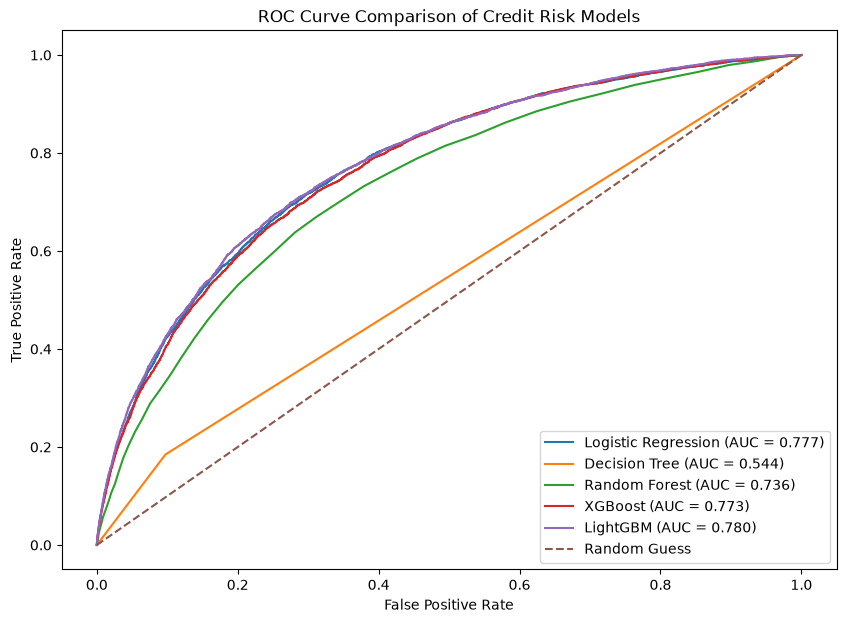

In [29]:
# Create the models dictionary

models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model
}


# Create the ROC curve figure
plt.figure(figsize=(10, 7))
# Loop through all trained models

for name, model in models.items():

    
    # Logistic Regression uses scaled validation data
    
    # It was trained using X_train_scaled, so the validation data must also be scaled.

    if name == "Logistic Regression":

        # Get probability of the Defaulter class
        probs = model.predict_proba(
            X_valid_scaled
        )[:, 1]

    
    # Tree-based models use original validation data
 
    # Decision Tree, Random Forest, XGBoost and LightGBM  were trained without scaling.

    else:

        # Get probability of the Defaulter class
        probs = model.predict_proba(
            X_valid
        )[:, 1]

    # Calculate False Positive Rate and True Positive Rate

    fpr, tpr, _ = roc_curve(
        y_valid,
        probs
    )
    # Calculate ROC-AUC score
    auc = roc_auc_score(
        y_valid,
        probs
    )

    # Plot the ROC curve

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )


# Add the random prediction baseline

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)


# Add axis labels
plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

# Add title
plt.title(
    "ROC Curve Comparison of Credit Risk Models"
)
# Display legend
plt.legend()


# Display the plot


plt.show()

LightGBM (0.780), Logistic Regression (0.777), and XGBoost (0.773) performed almost the same, showing that they were similarly good at ranking customers according to their risk of default. Random Forest (0.736) performed worse than these three, while Decision Tree (0.544) performed only slightly better than random guessing. Overall, LightGBM had the highest ROC-AUC, but the difference was small. Therefore, ROC-AUC alone was not enough to choose the best model, so precision, recall, F1-score, and threshold tuning were also considered.

## 15. Precision -recall curve comparison

The Precision-Recall curve shows how well the models identify defaulters while avoiding too many false alarms. It is especially useful because the dataset has many more non-defaulters than defaulters.

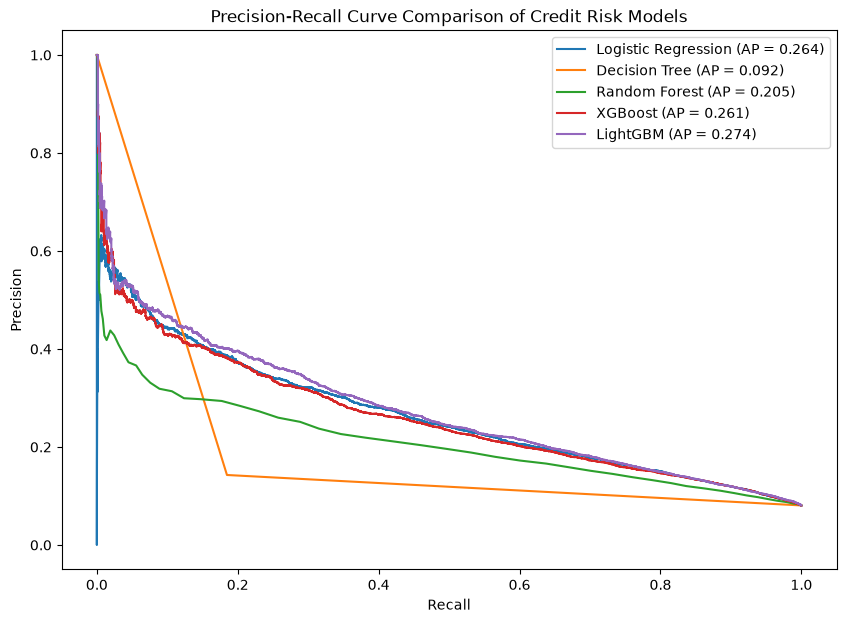

In [30]:

# Create dictionary of trained models

models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model
}


# Set figure size


plt.figure(figsize=(10, 7))



# Loop through each trained model


for name, model in models.items():

    # Logistic Regression was trained using scaled data
    # Therefore, validation data must also be scaled

    if name == "Logistic Regression":

        probs = model.predict_proba(
            X_valid_scaled
        )[:, 1]

    # Tree-based models were trained without scaling

    else:

        probs = model.predict_proba(
            X_valid
        )[:, 1]


    # Calculate Precision and Recall


    precision, recall, _ = precision_recall_curve(
        y_valid,
        probs
    )

    # Calculate Average Precision (AP)


    ap = average_precision_score(
        y_valid,
        probs
    )


    # Plot the Precision-Recall curve


    plt.plot(
        recall,
        precision,
        label=f"{name} (AP = {ap:.3f})"
    )


# Add axis labels


plt.xlabel("Recall")

plt.ylabel("Precision")


# Add title


plt.title(
    "Precision-Recall Curve Comparison of Credit Risk Models"
)



# Display legend


plt.legend()


# Display the plot


plt.show()

LightGBM (AP = 0.274) performed best, followed closely by Logistic Regression (0.264) and XGBoost (0.261). Random Forest and Decision Tree performed worse. Overall, the results show that LightGBM is the strongest model, but precision decreases as the model tries to identify more defaulters, which is why threshold tuning is important.

## 16. Cross-Validated Baseline Comparison 

The leaderboard above is based on a single 80/20 train/validation split. With ROC-AUC scores as close as LightGBM's 0.780 vs. Logistic Regression's 0.777, that ranking could easily be noise from the split itself.

Therefore, the comparison below checks how consistently the five models perform by dividing the training data into five groups and training each model five times, using a different group for validation each time. SMOTE is applied only to the training portion of each group, while the validation portion remains unchanged. Logistic Regression is scaled because it requires scaling, while the tree-based models do not. ROC-AUC is calculated for each run, and the code then calculates the average ROC-AUC and standard deviation to show which model performs best and most consistently.

In [32]:

cv_3fold = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Focus on the three strongest baseline models
cv_pipelines = {
    
    "Logistic Regression": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            random_state=42,
            max_iter=1000
        ))
    ]),

    "XGBoost": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", XGBClassifier(
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        ))
    ]),

    "LightGBM": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", LGBMClassifier(
            random_state=42,
            verbosity=-1,
            n_jobs=-1
        ))
    ])
}

cv_results = []

# Run cross-validation
for name, pipe in cv_pipelines.items():

    print(f"Running {name}...")

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv_3fold,
        scoring="roc_auc",
        n_jobs=1
    )

    cv_results.append({
        "Model": name,
        "CV ROC-AUC Mean": scores.mean(),
        "CV ROC-AUC Std": scores.std()
    })

    print(
        f"{name}: "
        f"ROC-AUC = {scores.mean():.4f} "
        f"(+/- {scores.std():.4f})"
    )

# Create results table
cv_results_df = (
    pd.DataFrame(cv_results)
    .sort_values(
        "CV ROC-AUC Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

display(cv_results_df)

Running Logistic Regression...
Logistic Regression: ROC-AUC = 0.7722 (+/- 0.0022)
Running XGBoost...
XGBoost: ROC-AUC = 0.7624 (+/- 0.0031)
Running LightGBM...
LightGBM: ROC-AUC = 0.7748 (+/- 0.0022)


,Model,CV ROC-AUC Mean,CV ROC-AUC Std
0,LightGBM,0.774822,0.002191
1,Logistic Regression,0.772224,0.002241
2,XGBoost,0.762442,0.003075


The cross-validation results show that LightGBM performed best, with an average ROC-AUC of 0.775, followed closely by Logistic Regression at 0.772, while XGBoost scored 0.762. The small standard deviations show that all three models performed consistently across the three folds. Overall, LightGBM is the strongest baseline model, although its advantage over Logistic Regression is very small.

## 17. SMOTE vs. Class-Weighting

SMOTE was used everywhere above, but it's not the only way to handle the 92/8 imbalance, and it's considerably more expensive than simply telling the model to weight the minority class more heavily. Here I train the two strongest baseline families - Logistic Regression and LightGBM - using class_weight='balanced /is_unbalance=True instead of SMOTE, on the *original* (non-resampled) training data, and compare against the SMOTE versions already in results_df.

In [33]:

# CLASS-WEIGHTING AS AN ALTERNATIVE TO SMOTE


# 1. Logistic Regression with class weighting
# Instead of using SMOTE, the model gives more importance to the minority class (Defaulters).

log_model_cw = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

# Scale the original training data
X_train_scaled_cw = scaler.fit_transform(X_train)

# Scale the validation data using the same scaler
X_valid_scaled_cw = scaler.transform(X_valid)

# Train the model
log_model_cw.fit(
    X_train_scaled_cw,
    y_train
)

# Make predictions
log_cw_pred = log_model_cw.predict(X_valid_scaled_cw)

# Get probability predictions
log_cw_prob = log_model_cw.predict_proba(
    X_valid_scaled_cw
)[:, 1]

# Evaluate the model
evaluate_model(
    "Logistic Regression (class_weight)",
    y_valid,
    log_cw_pred,
    log_cw_prob
)


# 2. LightGBM with class weighting is_unbalance=True tells LightGBM to give more importance to the minority class without using SMOTE.

lgbm_model_cw = LGBMClassifier(
    random_state=42,
    is_unbalance=True,
    verbosity=-1
)

# Train using the original training data
lgbm_model_cw.fit(
    X_train,
    y_train
)

# Make predictions
lgbm_cw_pred = lgbm_model_cw.predict(X_valid)

# Get probability predictions
lgbm_cw_prob = lgbm_model_cw.predict_proba(
    X_valid
)[:, 1]

# Evaluate the model
evaluate_model(
    "LightGBM (is_unbalance)",
    y_valid,
    lgbm_cw_pred,
    lgbm_cw_prob
)



# 3. Update model comparison table


results_df = (
    pd.DataFrame(results)
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,LightGBM (is_unbalance),0.726111,0.186047,0.708963,0.294746,0.787347
1,LightGBM,0.919695,0.565000,0.022759,0.043756,0.779973
2,Logistic Regression (class_weight),0.711445,0.176961,0.705136,0.282921,0.776778
3,Logistic Regression,0.919760,0.546296,0.035650,0.066931,0.776599
4,XGBoost,0.918801,0.477165,0.061027,0.108214,0.773136
5,Random Forest,0.919288,0.514286,0.003625,0.007200,0.735794
6,Decision Tree,0.844739,0.142879,0.184693,0.161117,0.543698


The results show that class weighting improved the models' ability to identify defaulters. LightGBM with is_unbalance=True achieved the highest recall (70.9%) and the highest ROC-AUC (0.787), compared with the original LightGBM's recall of only 2.3%. However, its precision dropped to 18.6%, meaning it produces more false alarms. Overall, class-weighted LightGBM performs better for identifying defaulters, making it a strong alternative to SMOTE for this credit-risk problem.

## 18. Hyperparameter tuning

Hyperparameter tuning is important because the default settings are not necessarily the best settings for our dataset. By testing different combinations, we can improve the model's ability to distinguish between customers who are likely to default and those who are not.

In our project, the baseline LightGBM achieved a ROC-AUC of 0.780. Hyperparameter tuning gives the opportunity to improve this performance while also controlling the model's complexity and reducing the risk of overfitting.

In [ ]:


# 1. LightGBM model

lgbm_model_tune = LGBMClassifier(
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    is_unbalance=True
)

# 2. Smaller search space

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth": [5, 10, -1],
    "min_child_samples": [50, 100],
    "colsample_bytree": [0.8, 1.0]
}


# 3. 3-fold cross-validation
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# 4. Randomized search

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_model_tune,
    param_distributions=param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# 5. Run tuning

lgbm_search.fit(
    X_train,
    y_train
)

# 6. Best parameters


print("\nBest Parameters:")
print(lgbm_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(lgbm_search.best_score_, 4))

# 7. Retrieve best model


best_lgbm = lgbm_search.best_estimator_


# 8. Evaluate on untouched validation data


lgbm_tuned_pred = best_lgbm.predict(X_valid)

lgbm_tuned_prob = best_lgbm.predict_proba(
    X_valid
)[:, 1]

evaluate_model(
    "Tuned LightGBM",
    y_valid,
    lgbm_tuned_pred,
    lgbm_tuned_prob
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Parameters:
{'num_leaves': 31, 'n_estimators': 300, 'min_child_samples': 100, 'max_depth': 10, 'learning_rate': 0.03, 'colsample_bytree': 1.0}

Best Cross-Validation ROC-AUC:
0.7831


## 19. Evaluate the tuned class

In [36]:



# Retrieve the best tuned model
best_lgbm = lgbm_search.best_estimator_

# Make predictions on untouched validation data
lgbm_tuned_pred = best_lgbm.predict(X_valid)

# Get probability predictions
lgbm_tuned_prob = best_lgbm.predict_proba(
    X_valid
)[:, 1]

# Classification report
print(
    classification_report(
        y_valid,
        lgbm_tuned_pred,
        target_names=[
            "Non-Defaulter",
            "Defaulter"
        ]
    )
)

               precision    recall  f1-score   support

Non-Defaulter       0.97      0.72      0.83     56538
    Defaulter       0.19      0.72      0.29      4965

     accuracy                           0.72     61503
    macro avg       0.58      0.72      0.56     61503
 weighted avg       0.90      0.72      0.78     61503



The model catches about 72% of customers who actually default, which is good. However, only 19% of the customers it flags as risky actually default, meaning there are many false alarms. Overall, the model is 72% accurate. The F1-score of 0.29 for defaulters shows that the model still needs to balance catching defaulters with avoiding false alarms.

## 20. Threshold tuning for tuned lightgbm


Check which probability threshold works best for the LightGBM model. First, it gets the probability that each customer will default. It then tests different thresholds, from 0.50 to 0.10, and converts the probabilities into either default (1) or non-default (0). For each threshold, it calculates accuracy, precision, recall, and F1-score, then puts the results into a table.

In [37]:

# Get probability predictions
lgbm_valid_prob = best_lgbm.predict_proba(
    X_valid
)[:, 1]

# Thresholds to test
thresholds = [0.50, 0.40, 0.30, 0.20, 0.10]

threshold_results = []

for threshold in thresholds:

    predictions = (
        lgbm_valid_prob >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        y_valid,
        predictions
    )

    precision = precision_score(
        y_valid,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_valid,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_valid,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(threshold_df)

,Threshold,Accuracy,Precision,Recall,F1-score
0,0.5,0.722908,0.185544,0.717623,0.294853
1,0.4,0.617092,0.151248,0.811682,0.254983
2,0.3,0.485245,0.125042,0.896475,0.219472
3,0.2,0.327708,0.103369,0.954884,0.186543
4,0.1,0.149798,0.086211,0.992951,0.158648


The results show that 0.50 is the best threshold based on F1-score. At this threshold, the model catches about 72% of actual defaulters while keeping a better balance between precision and recall than the lower thresholds. Lowering the threshold to 0.20 or 0.10 catches more defaulters, but it also creates many more false alarms and reduces the F1-score. Therefore, 0.50 is the most balanced choice among the tested thresholds, unless the business decides that catching almost every defaulter is more important than avoiding false alarms.

## 21. Classification Report - Tuned Lightgbm At 0.5 Threshold

In [38]:

# Get probability predictions
y_prob = best_lgbm.predict_proba(X_valid)[:, 1]

# Apply 0.5 threshold
y_pred_05 = (
    y_prob >= 0.50
).astype(int)

# Generate classification report
print(
    classification_report(
        y_valid,
        y_pred_05,
        target_names=[
            "Non-Defaulter",
            "Defaulter"
        ]
    )
)

               precision    recall  f1-score   support

Non-Defaulter       0.97      0.72      0.83     56538
    Defaulter       0.19      0.72      0.29      4965

     accuracy                           0.72     61503
    macro avg       0.58      0.72      0.56     61503
 weighted avg       0.90      0.72      0.78     61503



At a 0.5 threshold, the tuned LightGBM correctly identifies about 72% of actual defaulters. However, its precision for defaulters is only 19%, meaning many customers predicted as defaulters are actually non-defaulters. The model performs much better for non-defaulters, with 97% precision and 72% recall. Overall accuracy is 72%, while the defaulter F1-score of 0.29 shows that there is still a trade-off between catching defaulters and avoiding false alarms.

## 22. Save the final model

In [39]:

import pickle

# Final selected model
final_model = lgbm_model_cw

# Final probability threshold
final_threshold = 0.50

# Save model and threshold together
model_package = {
    "model": final_model,
    "threshold": final_threshold
}

# Save the model
with open("credit_risk_model.pkl", "wb") as file:
    pickle.dump(model_package, file)

print("Final credit risk model and threshold saved successfully.")

Final credit risk model and threshold saved successfully.


## 23. Calibration Curve

Check how reliable the probability predictions from the class-weighted LightGBM model are. First, get the model's predicted probability of default for each customer. Then divide the predictions into 10 groups and compare the predicted probabilities with the actual default rates in each group. The calibration curve is plotted against a diagonal line, which represents perfect calibration. The code below also calculates the Brier Score, where a lower score means the predicted probabilities are closer to the actual outcomes. This is important in credit risk because we want the model's probabilities to be meaningful—for example, customers given a 70% default probability should actually have a default rate close to 70%.

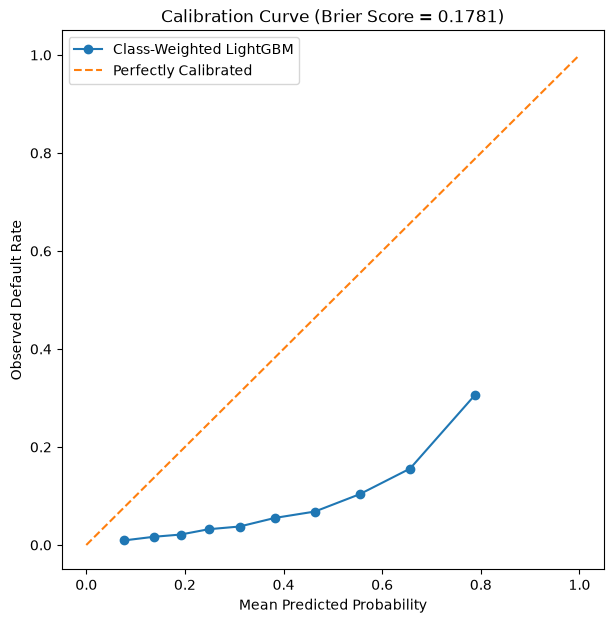

Brier Score: 0.1781 (lower is better)


In [ ]:


# Get probabilities from the final model
lgbm_valid_prob = lgbm_model_cw.predict_proba(X_valid)[:, 1]

# Calculate calibration values
prob_true, prob_pred = calibration_curve(
    y_valid,
    lgbm_valid_prob,
    n_bins=10,
    strategy="quantile"
)

# Calculate Brier score
brier = brier_score_loss(
    y_valid,
    lgbm_valid_prob
)

# Plot calibration curve
plt.figure(figsize=(7, 7))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Class-Weighted LightGBM"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfectly Calibrated"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Rate")

plt.title(
    f"Calibration Curve (Brier Score = {brier:.4f})"
)

plt.legend()
plt.show()

print(
    f"Brier Score: {brier:.4f} "
    "(lower is better)"
)

The calibration curve shows that the LightGBM model's predicted probabilities are higher than the actual default rates. For example, when the model gives a customer a high probability of default, the actual number of customers who default is much lower. This means the model is good at identifying risky customers but its probability estimates are not very accurate. The Brier score of 0.1781 also shows that the probability predictions can be improved, since a lower score is better.

## 24. Confusion Matrix

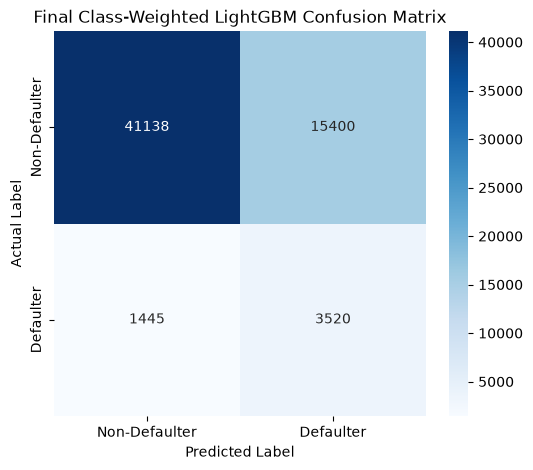

In [ ]:

# 1. Make predictions on the untouched validation data
final_pred = lgbm_model_cw.predict(X_valid)

# 2. Create the confusion matrix


cm = confusion_matrix(
    y_valid,
    final_pred
)


# 3. Plot the confusion matrix


plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Defaulter", "Defaulter"],
    yticklabels=["Non-Defaulter", "Defaulter"]
)

# 4. Add title and axis labels


plt.title("Final Class-Weighted LightGBM Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# 5. Display the plot


plt.show()

The confusion matrix shows that the model correctly identified 41,138 non-defaulters and 3,520 defaulters. However, it incorrectly classified 15,400 non-defaulters as defaulters and missed 1,445 actual defaulters. This means the model is good at catching defaulters, but it also produces many false alarms by flagging customers who would actually repay. Overall, the model catches about 71% of actual defaulters, while the main weakness is the high number of false positives.

## 25. Error Analysis

 Investigate which customers the model got wrong, especially the false positives and false negatives, and understand where the model may need improvement.

In [43]:
# Create dataframe from validation data
error_analysis = pd.DataFrame(
    X_valid,
    columns=X_valid.columns
)

# Add actual values
error_analysis["Actual"] = y_valid.values

# Get predicted probabilities
error_analysis["Predicted_Probability"] = (
    lgbm_model_cw.predict_proba(X_valid)[:, 1]
)

# Get predictions at 0.50 threshold
error_analysis["Predicted"] = (
    error_analysis["Predicted_Probability"] >= 0.50
).astype(int)

# Identify correct and incorrect predictions
error_analysis["Correct_Prediction"] = (
    error_analysis["Actual"] ==
    error_analysis["Predicted"]
)

# Display first rows
error_analysis.head()

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_SUM,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_MAX,BUREAU_CREDIT_DAY_OVERDUE_MEAN,BUREAU_CREDIT_DAY_OVERDUE_SUM,BUREAU_CREDIT_DAY_OVERDUE_MIN,BUREAU_CREDIT_DAY_OVERDUE_MAX,BUREAU_DAYS_CREDIT_ENDDATE_MEAN,BUREAU_DAYS_CREDIT_ENDDATE_SUM,BUREAU_DAYS_CREDIT_ENDDATE_MIN,BUREAU_DAYS_CREDIT_ENDDATE_MAX,BUREAU_DAYS_ENDDATE_FACT_MEAN,BUREAU_DAYS_ENDDATE_FACT_SUM,BUREAU_DAYS_ENDDATE_FACT_MIN,BUREAU_DAYS_ENDDATE_FACT_MAX,BUREAU_AMT_CREDIT_MAX_OVERDUE_MEAN,BUREAU_AMT_CREDIT_MAX_OVERDUE_SUM,BUREAU_AMT_CREDIT_MAX_OVERDUE_MIN,BUREAU_AMT_CREDIT_MAX_OVERDUE_MAX,BUREAU_CNT_CREDIT_PROLONG_MEAN,BUREAU_CNT_CREDIT_PROLONG_SUM,BUREAU_CNT_CREDIT_PROLONG_MIN,BUREAU_CNT_CREDIT_PROLONG_MAX,BUREAU_AMT_CREDIT_SUM_MEAN,BUREAU_AMT_CREDIT_SUM_SUM,BUREAU_AMT_CREDIT_SUM_MIN,BUREAU_AMT_CREDIT_SUM_MAX,BUREAU_AMT_CREDIT_SUM_DEBT_MEAN,BUREAU_AMT_CREDIT_SUM_DEBT_SUM,BUREAU_AMT_CREDIT_SUM_DEBT_MIN,BUREAU_AMT_CREDIT_SUM_DEBT_MAX,BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN,BUREAU_AMT_CREDIT_SUM_LIMIT_SUM,BUREAU_AMT_CREDIT_SUM_LIMIT_MIN,BUREAU_AMT_CREDIT_SUM_LIMIT_MAX,BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN,BUREAU_AMT_CREDIT_SUM_OVERDUE_SUM,BUREAU_AMT_CREDIT_SUM_OVERDUE_MIN,BUREAU_AMT_CREDIT_SUM_OVERDUE_MAX,BUREAU_DAYS_CREDIT_UPDATE_MEAN,BUREAU_DAYS_CREDIT_UPDATE_SUM,BUREAU_DAYS_CREDIT_UPDATE_MIN,BUREAU_DAYS_CREDIT_UPDATE_MAX,BUREAU_AMT_ANNUITY_MEAN,BUREAU_AMT_ANNUITY_SUM,BUREAU_AMT_ANNUITY_MIN,BUREAU_AMT_ANNUITY_MAX,BUREAU_BB_MONTHS_COUNT_MEAN,BUREAU_BB_MONTHS_COUNT_SUM,BUREAU_BB_MONTHS_COUNT_MIN,BUREAU_BB_MONTHS_COUNT_MAX,BUREAU_BB_MONTHS_MIN_MEAN,BUREAU_BB_MONTHS_MIN_SUM,BUREAU_BB_MONTHS_MIN_MIN,BUREAU_BB_MONTHS_MIN_MAX,BUREAU_BB_MONTHS_MAX_MEAN,BUREAU_BB_MONTHS_MAX_SUM,BUREAU_BB_MONTHS_MAX_MIN,BUREAU_BB_MONTHS_MAX_MAX,BUREAU_BB_STATUS_0_MEAN,BUREAU_BB_STATUS_0_SUM,BUREAU_BB_STATUS_0_MIN,BUREAU_BB_STATUS_0_MAX,BUREAU_BB_STATUS_1_MEAN,BUREAU_BB_STATUS_1_SUM,BUREAU_BB_STATUS_1_MIN,BUREAU_BB_STATUS_1_MAX,BUREAU_BB_STATUS_2_MEAN,BUREAU_BB_STATUS_2_SUM,BUREAU_BB_STATUS_2_MIN,BUREAU_BB_STATUS_2_MAX,BUREAU_BB_STATUS_3_MEAN,BUREAU_BB_STATUS_3_SUM,BUREAU_BB_STATUS_3_MIN,BUREAU_BB_STATUS

## 26. Separate False Positives and False Negatives

In [44]:

# False Positives:
# Predicted default, but actually did not default
false_positive = error_analysis[
    (error_analysis["Actual"] == 0) &
    (error_analysis["Predicted"] == 1)
].copy()

# False Negatives:
# Predicted non-default, but actually defaulted
false_negative = error_analysis[
    (error_analysis["Actual"] == 1) &
    (error_analysis["Predicted"] == 0)
].copy()

# Display counts
print(f"False Positives: {len(false_positive)}")
print(f"False Negatives: {len(false_negative)}")

False Positives: 15400
False Negatives: 1445


## 27. Descriptive statistics of misclassified customers

In [45]:


# Combine false positives and false negatives
misclassified = pd.concat(
    [false_positive, false_negative],
    axis=0
)

# Display descriptive statistics
misclassified.describe()

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_SUM,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_MAX,BUREAU_CREDIT_DAY_OVERDUE_MEAN,BUREAU_CREDIT_DAY_OVERDUE_SUM,BUREAU_CREDIT_DAY_OVERDUE_MIN,BUREAU_CREDIT_DAY_OVERDUE_MAX,BUREAU_DAYS_CREDIT_ENDDATE_MEAN,BUREAU_DAYS_CREDIT_ENDDATE_SUM,BUREAU_DAYS_CREDIT_ENDDATE_MIN,BUREAU_DAYS_CREDIT_ENDDATE_MAX,BUREAU_DAYS_ENDDATE_FACT_MEAN,BUREAU_DAYS_ENDDATE_FACT_SUM,BUREAU_DAYS_ENDDATE_FACT_MIN,BUREAU_DAYS_ENDDATE_FACT_MAX,BUREAU_AMT_CREDIT_MAX_OVERDUE_MEAN,BUREAU_AMT_CREDIT_MAX_OVERDUE_SUM,BUREAU_AMT_CREDIT_MAX_OVERDUE_MIN,BUREAU_AMT_CREDIT_MAX_OVERDUE_MAX,BUREAU_CNT_CREDIT_PROLONG_MEAN,BUREAU_CNT_CREDIT_PROLONG_SUM,BUREAU_CNT_CREDIT_PROLONG_MIN,BUREAU_CNT_CREDIT_PROLONG_MAX,BUREAU_AMT_CREDIT_SUM_MEAN,BUREAU_AMT_CREDIT_SUM_SUM,BUREAU_AMT_CREDIT_SUM_MIN,BUREAU_AMT_CREDIT_SUM_MAX,BUREAU_AMT_CREDIT_SUM_DEBT_MEAN,BUREAU_AMT_CREDIT_SUM_DEBT_SUM,BUREAU_AMT_CREDIT_SUM_DEBT_MIN,BUREAU_AMT_CREDIT_SUM_DEBT_MAX,BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN,BUREAU_AMT_CREDIT_SUM_LIMIT_SUM,BUREAU_AMT_CREDIT_SUM_LIMIT_MIN,BUREAU_AMT_CREDIT_SUM_LIMIT_MAX,BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN,BUREAU_AMT_CREDIT_SUM_OVERDUE_SUM,BUREAU_AMT_CREDIT_SUM_OVERDUE_MIN,BUREAU_AMT_CREDIT_SUM_OVERDUE_MAX,BUREAU_DAYS_CREDIT_UPDATE_MEAN,BUREAU_DAYS_CREDIT_UPDATE_SUM,BUREAU_DAYS_CREDIT_UPDATE_MIN,BUREAU_DAYS_CREDIT_UPDATE_MAX,BUREAU_AMT_ANNUITY_MEAN,BUREAU_AMT_ANNUITY_SUM,BUREAU_AMT_ANNUITY_MIN,BUREAU_AMT_ANNUITY_MAX,BUREAU_BB_MONTHS_COUNT_MEAN,BUREAU_BB_MONTHS_COUNT_SUM,BUREAU_BB_MONTHS_COUNT_MIN,BUREAU_BB_MONTHS_COUNT_MAX,BUREAU_BB_MONTHS_MIN_MEAN,BUREAU_BB_MONTHS_MIN_SUM,BUREAU_BB_MONTHS_MIN_MIN,BUREAU_BB_MONTHS_MIN_MAX,BUREAU_BB_MONTHS_MAX_MEAN,BUREAU_BB_MONTHS_MAX_SUM,BUREAU_BB_MONTHS_MAX_MIN,BUREAU_BB_MONTHS_MAX_MAX,BUREAU_BB_STATUS_0_MEAN,BUREAU_BB_STATUS_0_SUM,BUREAU_BB_STATUS_0_MIN,BUREAU_BB_STATUS_0_MAX,BUREAU_BB_STATUS_1_MEAN,BUREAU_BB_STATUS_1_SUM,BUREAU_BB_STATUS_1_MIN,BUREAU_BB_STATUS_1_MAX,BUREAU_BB_STATUS_2_MEAN,BUREAU_BB_STATUS_2_SUM,BUREAU_BB_STATUS_2_MIN,BUREAU_BB_STATUS_2_MAX,BUREAU_BB_STATUS_3_MEAN,BUREAU_BB_STATUS_3_SUM,BUREAU_BB_STATUS_3_MIN,BUREAU_BB_STATUS

## 28. Compare correct vs misclassified customers

compare customers that the model predicted correctly with customers that the model got wrong.

In [46]:


# Select correctly predicted customers
correct_predictions = error_analysis[
    error_analysis["Correct_Prediction"] == True
]

# Compare mean values
print("Correct Predictions Mean")

print(
    correct_predictions.mean(
        numeric_only=True
    )
)

print("\nMisclassified Mean")

print(
    misclassified.mean(
        numeric_only=True
    )
)

Correct Predictions Mean
CNT_CHILDREN                    0.398518
AMT_INCOME_TOTAL           171884.783597
AMT_CREDIT                 615271.193067
AMT_ANNUITY                 27487.865276
AMT_GOODS_PRICE            557598.561669
                               ...      
EMERGENCYSTATE_MODE_Yes         0.007255
Actual                          0.078821
Predicted_Probability           0.290006
Predicted                       0.078821
Correct_Prediction              1.000000
Length: 791, dtype: float64

Misclassified Mean
CNT_CHILDREN                    0.475571
AMT_INCOME_TOTAL           159807.243553
AMT_CREDIT                 551397.993767
AMT_ANNUITY                 26109.838825
AMT_GOODS_PRICE            483442.881211
                               ...      
EMERGENCYSTATE_MODE_Yes         0.008727
Actual                          0.085782
Predicted_Probability           0.622316
Predicted                       0.914218
Correct_Prediction              0.000000
Length: 791, dtype: float

**Interpretation - Correct vs. Misclassified Customers**

Comparing the average feature values between correctly classified and misclassified customers shows that the model's errors are not random, and are not concentrated in one obvious customer segment.

- **Actual default rate is nearly identical between the two groups** (7.9% for correct predictions vs. 8.6% for misclassified), meaning the model isn't systematically failing on one class - its mistakes are spread across both defaulters and non-defaulters.
- **Demographic and financial differences are modest.** Misclassified customers have slightly more children (0.48 vs. 0.40), slightly lower income (159,807 vs. 171,885), and slightly smaller loan/goods amounts than correctly classified customers - directionally sensible, but too small to be the main driver of the errors.
- **The clearest signal is the model's own predicted probability.** Correctly classified customers had an average predicted probability of just 0.29, while misclassified customers averaged 0.62 - well above the 0.50 decision threshold. This shows the model's mistakes cluster around genuinely borderline cases near the decision boundary, rather than being confident, "obvious" failures.
- **Most errors are false alarms rather than missed defaulters.** 91.4% of misclassified customers were predicted as defaulters (vs. only 7.9% in the correctly classified group), which means the majority of mistakes are the model flagging a customer as high-risk when they actually repaid, not the model missing a genuine defaulter.

**Takeaway:** the model struggles most with applicants who sit close to the decision boundary rather than with a specific income or family-size segment, and its errors skew toward over-flagging safe customers as risky rather than under-flagging risky ones - a reasonable trade-off given that missing a true defaulter is typically costlier to a lender than a false alarm, but one that could still be tightened with further threshold or calibration work.

## 29. Age Distribution: Correct vs Misclassified

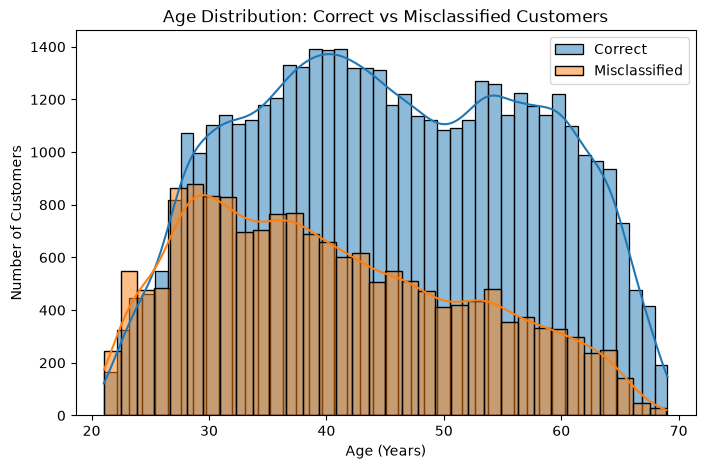

In [47]:


plt.figure(figsize=(8, 5))

# Correctly predicted customers
sns.histplot(
    correct_predictions["AGE_YEARS"],
    label="Correct",
    kde=True
)

# Misclassified customers
sns.histplot(
    misclassified["AGE_YEARS"],
    label="Misclassified",
    kde=True
)

plt.title("Age Distribution: Correct vs Misclassified Customers")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Customers")
plt.legend()

plt.show()

**Interpretation - Age Distribution: Correct vs. Misclassified Customers**

The age distributions of correctly classified and misclassified customers follow a broadly similar shape, but misclassifications are noticeably concentrated among younger applicants. The misclassified (orange) distribution peaks early, around ages 28-35, and then declines steadily, while the correctly classified (blue) distribution stays elevated much longer, remaining strong through the 40s and into the mid-50s.

A distinct spike in misclassifications appears around age 22-23, standing out from the surrounding trend - suggesting very young applicants are disproportionately difficult for the model to classify correctly, likely because they have thinner credit and employment histories for the model to draw on. In contrast, applicants aged 55 and older are classified correctly much more reliably, with misclassifications dropping off sharply in this range.

**Takeaway:** the model's errors skew toward younger applicants, particularly those in their early-to-mid twenties and thirties, while performance is more reliable for older, likely more established applicants. This points to credit/employment history depth as a plausible driver of model uncertainty, and suggests younger applicants may benefit from additional features or closer manual review in a production setting.

## 30. Income distribution: correct vs misclassified

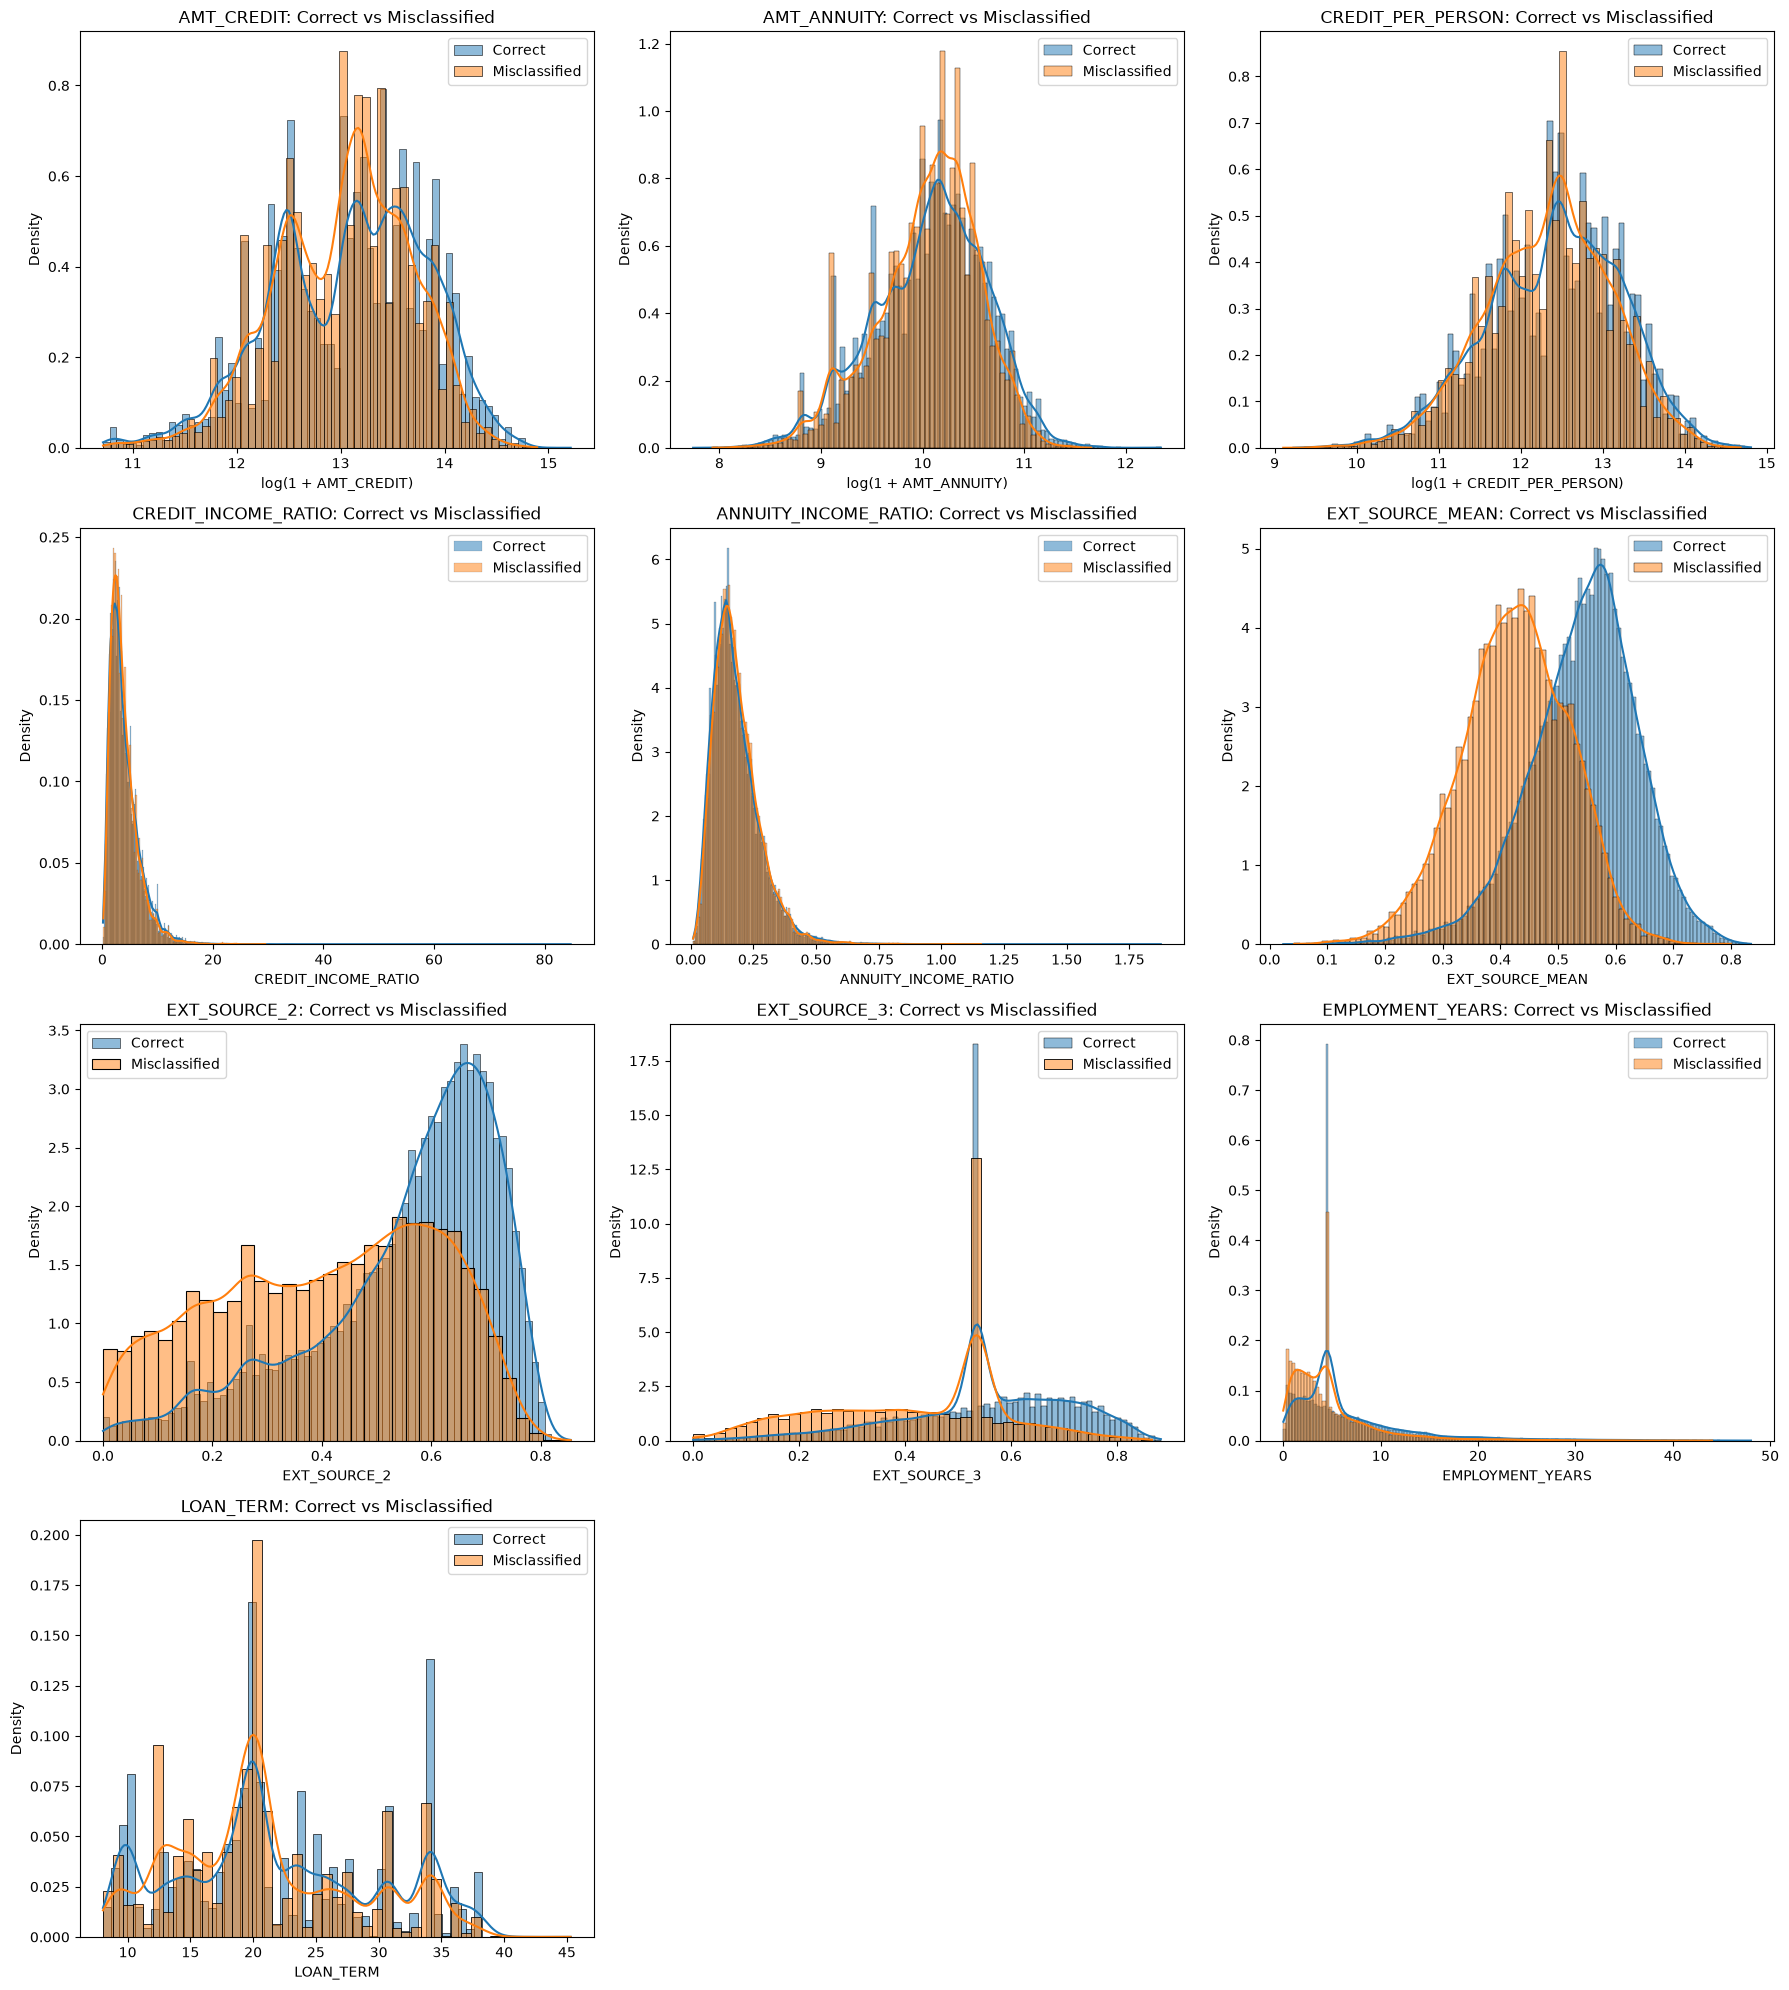

In [ ]:


# Features that need a log transform to be readable (heavily skewed)
skewed_features = ["AMT_CREDIT", "AMT_ANNUITY", "CREDIT_PER_PERSON"]

# Features that plot fine as-is
clean_features = [
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "EXT_SOURCE_MEAN",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "EMPLOYMENT_YEARS",
    "LOAN_TERM"
]

all_features = skewed_features + clean_features

# Grid layout: 3 plots per row, arranged horizontally
n_cols = 3
n_rows = -(-len(all_features) // n_cols)  # ceiling division

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(6 * n_cols, 5 * n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(all_features):

    ax = axes[i]
    log_transform = feature in skewed_features

    correct_vals = correct_predictions[feature]
    misclass_vals = misclassified[feature]

    if log_transform:
        correct_vals = np.log1p(correct_vals.clip(lower=0))
        misclass_vals = np.log1p(misclass_vals.clip(lower=0))
        xlabel = f"log(1 + {feature})"
    else:
        xlabel = feature

    # Correctly predicted customers
    sns.histplot(
        correct_vals,
        label="Correct",
        kde=True,
        stat="density",
        ax=ax
    )

    # Misclassified customers
    sns.histplot(
        misclass_vals,
        label="Misclassified",
        kde=True,
        stat="density",
        ax=ax
    )

    ax.set_title(f"{feature}: Correct vs Misclassified")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.legend()

# Hide any unused subplot axes (if grid has extra cells)
for j in range(len(all_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 31. Feature Importance

In [49]:

# Get feature importance from the final model
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgbm_model_cw.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 10 features
feature_importance.head(10)

,Feature,Importance
675,EXT_SOURCE_MEAN,66
680,LOAN_TERM,65
664,ANNUITY_CREDIT_RATIO,64
3,AMT_ANNUITY,60
356,PREV_DAYS_LAST_DUE_1ST_VERSION_MAX,60
27,EXT_SOURCE_1,51
662,CREDIT_GOODS_RATIO,41
115,BUREAU_DAYS_CREDIT_ENDDATE_MAX,41
6,DAYS_BIRTH,35
533,INSTAL_DAYS_LATE_MAX,34


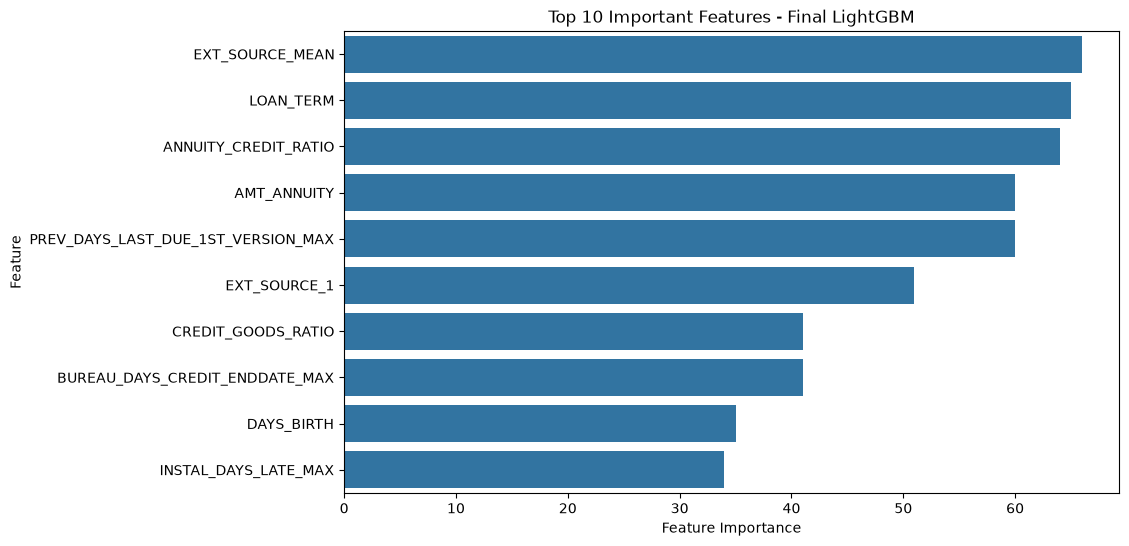

In [50]:

# PLOT TOP 10 FEATURE IMPORTANCES


plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features - Final LightGBM")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

## 32. Model Interpretability with SHAP

Built-in feature importance tells you which features the model leans on *overall*, but not the direction of the effect or how it behaved for a specific applicant. In credit risk that per-applicant explanation matters - regulators and internal risk teams typically expect a reason code for why someone was declined. SHAP values give both a global summary and an individual, additive explanation for any single prediction.

SHAP on the full validation set (61k rows x 700+ features) is expensive, so this samples a subset for the global summary plot, and pulls one concrete false-negative and one false-positive example from the error analysis above for individual explanations.

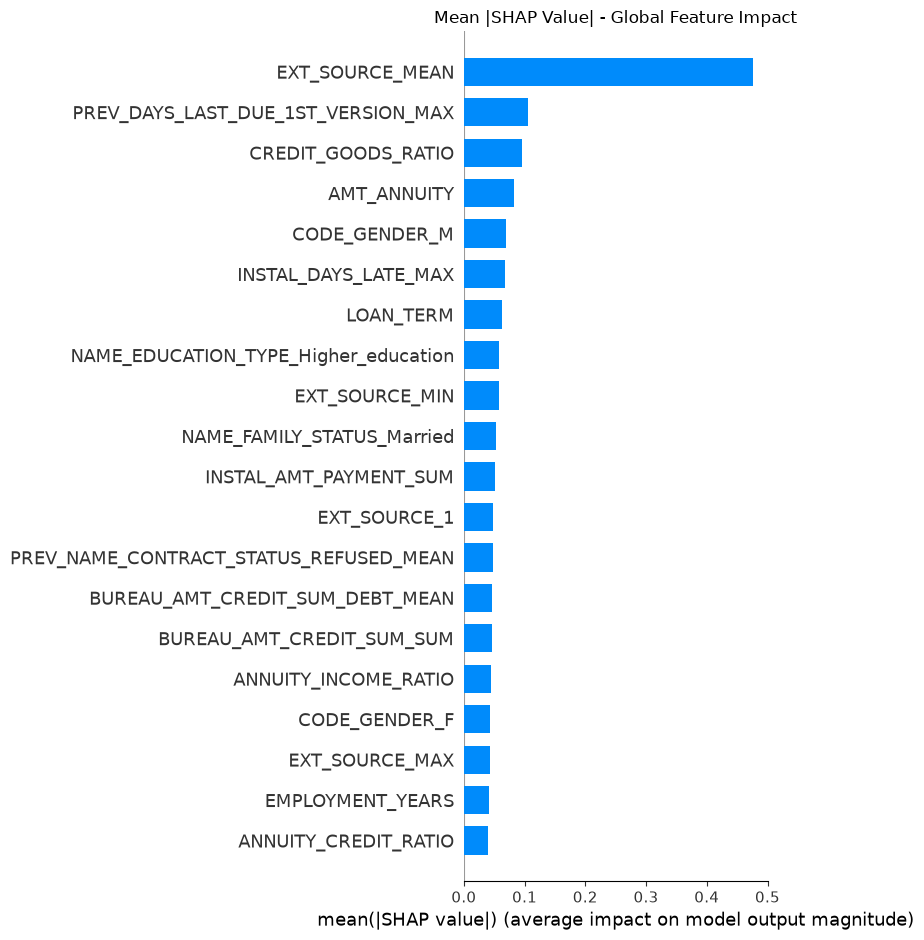

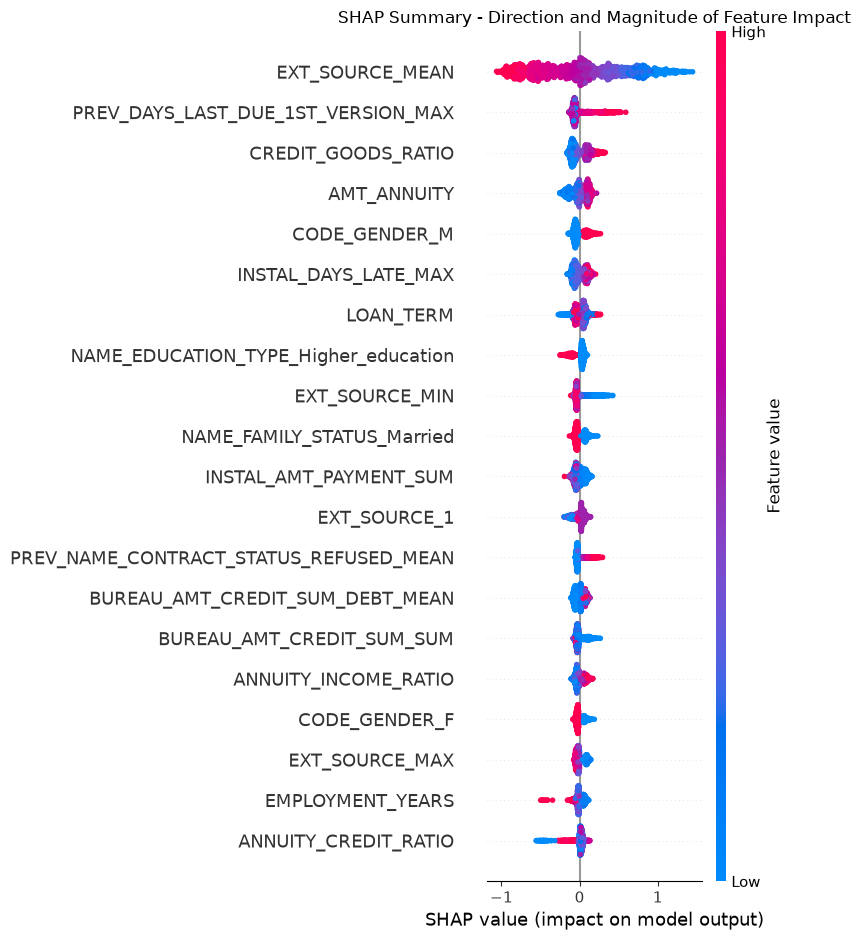

In [ ]:

# SHAP — GLOBAL FEATURE IMPACT
# Use the tuned class-weighted LightGBM model
lgbm_model_final = best_lgbm

# Sample validation data for faster SHAP calculation
shap_sample = X_valid.sample(
    n=min(2000, len(X_valid)),
    random_state=42
)

# Create SHAP explainer
explainer = shap.TreeExplainer(lgbm_model_final)

# Calculate SHAP values
shap_values = explainer.shap_values(shap_sample)

# Handle binary classification
if isinstance(shap_values, list):
    sv_default_class = shap_values[1]
else:
    sv_default_class = shap_values


# Global feature importance


shap.summary_plot(
    sv_default_class,
    shap_sample,
    plot_type="bar",
    show=False
)

plt.title("Mean |SHAP Value| - Global Feature Impact")
plt.tight_layout()
plt.show()
# SHAP summary plot

shap.summary_plot(
    sv_default_class,
    shap_sample,
    show=False
)

plt.title("SHAP Summary - Direction and Magnitude of Feature Impact")
plt.tight_layout()
plt.show()

False Negative: Actual defaulter predicted as non-defaulter


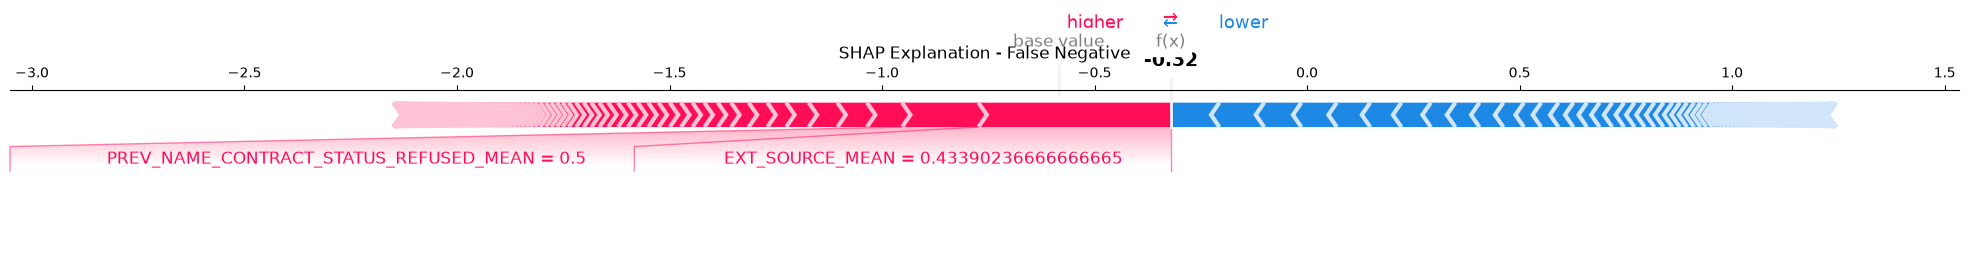

False Positive: Non-defaulter predicted as defaulter


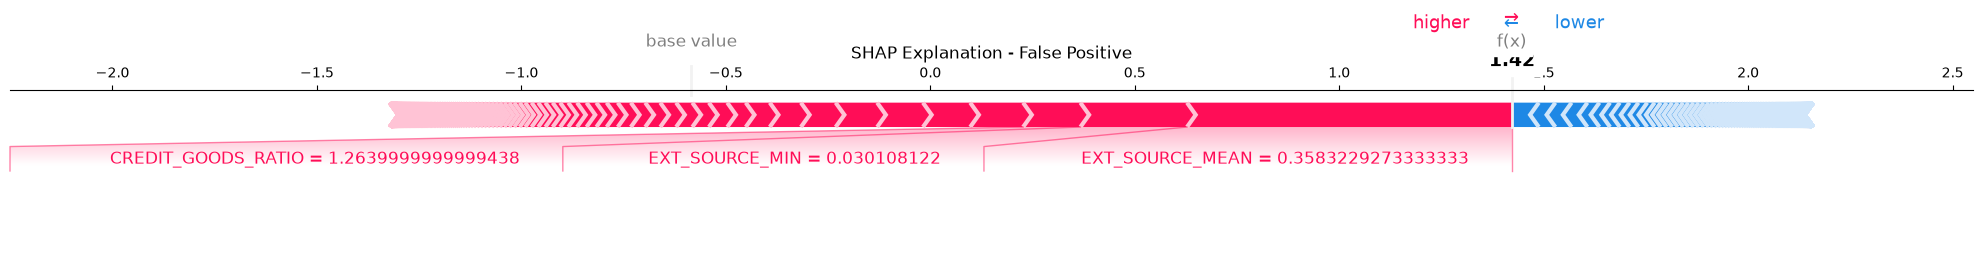

In [ ]:

# SHAP — INDIVIDUAL FALSE NEGATIVE AND FALSE POSITIVE


# Select one False Negative
fn_example = false_negative.drop(
    columns=[
        "Actual",
        "Predicted_Probability",
        "Predicted",
        "Correct_Prediction"
    ],
    errors="ignore"
).iloc[[0]]

# Select one False Positive
fp_example = false_positive.drop(
    columns=[
        "Actual",
        "Predicted_Probability",
        "Predicted",
        "Correct_Prediction"
    ],
    errors="ignore"
).iloc[[0]]

# Calculate SHAP values
fn_shap = explainer.shap_values(fn_example)
fp_shap = explainer.shap_values(fp_example)

# Handle binary classification
fn_sv = fn_shap[1] if isinstance(fn_shap, list) else fn_shap
fp_sv = fp_shap[1] if isinstance(fp_shap, list) else fp_shap


# False Negative

print("False Negative: Actual defaulter predicted as non-defaulter")

shap.force_plot(
    explainer.expected_value[1]
    if isinstance(explainer.expected_value, (list, np.ndarray))
    else explainer.expected_value,
    fn_sv[0],
    fn_example.iloc[0],
    matplotlib=True,
    show=False
)

plt.title("SHAP Explanation - False Negative")
plt.tight_layout()
plt.show()

# False Positive


print("False Positive: Non-defaulter predicted as defaulter")

shap.force_plot(
    explainer.expected_value[1]
    if isinstance(explainer.expected_value, (list, np.ndarray))
    else explainer.expected_value,
    fp_sv[0],
    fp_example.iloc[0],
    matplotlib=True,
    show=False
)

plt.title("SHAP Explanation - False Positive")
plt.tight_layout()
plt.show()

## 33. Fairness Check

In [ ]:

# FAIRNESS CHECK: RECALL BY GENDER


gender_cols = [
    c for c in error_analysis.columns
    if c.startswith("CODE_GENDER_")
]

print("Gender columns found:", gender_cols)

fairness_rows = []

for gcol in gender_cols:

    subset = error_analysis[
        error_analysis[gcol] == 1
    ]

    actual_defaulters = subset[
        subset["Actual"] == 1
    ]

    if len(actual_defaulters) == 0:
        continue

    recall = (
        actual_defaulters["Predicted"] == 1
    ).mean()

    fnr = 1 - recall

    fairness_rows.append({
        "Group": gcol.replace("CODE_GENDER_", ""),
        "N Applicants": len(subset),
        "N Actual Defaulters": len(actual_defaulters),
        "Defaulter Recall": recall,
        "False Negative Rate": fnr
    })

fairness_gender_df = pd.DataFrame(
    fairness_rows
)

display(fairness_gender_df)

Gender columns found: ['CODE_GENDER_F', 'CODE_GENDER_M', 'CODE_GENDER_XNA']


,Group,N Applicants,N Actual Defaulters,Defaulter Recall,False Negative Rate
0,F,40561,2836,0.653385,0.346615
1,M,20940,2129,0.782997,0.217003


In [ ]:

# FAIRNESS CHECK: RECALL BY AGE GROUP


age_bins = [18, 30, 40, 50, 60, 100]

age_labels = [
    "18-29",
    "30-39",
    "40-49",
    "50-59",
    "60+"
]

error_analysis["AGE_GROUP"] = pd.cut(
    error_analysis["AGE_YEARS"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

age_fairness_rows = []

for group in age_labels:

    subset = error_analysis[
        error_analysis["AGE_GROUP"] == group
    ]

    actual_defaulters = subset[
        subset["Actual"] == 1
    ]

    if len(actual_defaulters) == 0:
        continue

    recall = (
        actual_defaulters["Predicted"] == 1
    ).mean()

    fnr = 1 - recall

    age_fairness_rows.append({
        "Age Group": group,
        "N Applicants": len(subset),
        "N Actual Defaulters": len(actual_defaulters),
        "Defaulter Recall": recall,
        "False Negative Rate": fnr
    })

fairness_age_df = pd.DataFrame(
    age_fairness_rows
)

display(fairness_age_df)

,Age Group,N Applicants,N Actual Defaulters,Defaulter Recall,False Negative Rate
0,18-29,8864,1002,0.825349,0.174651
1,30-39,16484,1579,0.762508,0.237492
2,40-49,15285,1157,0.686258,0.313742
3,50-59,13612,867,0.603230,0.396770
4,60+,7258,360,0.477778,0.522222


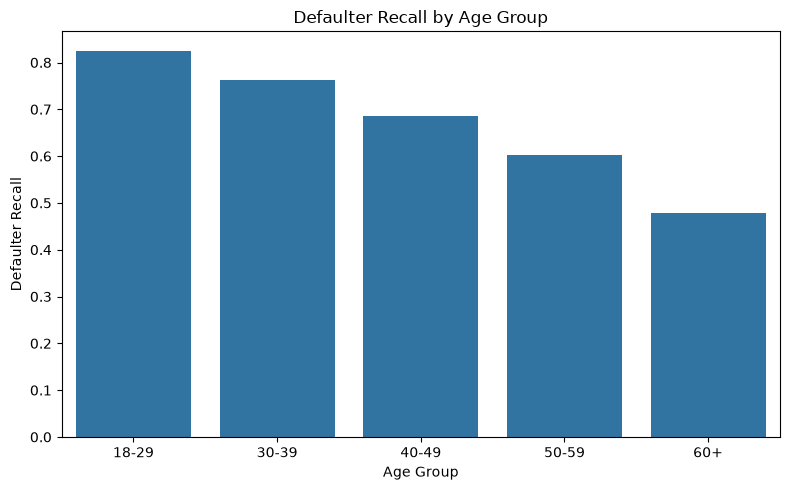

In [ ]:

# DEFALTER RECALL BY AGE GROUP


plt.figure(figsize=(8, 5))

sns.barplot(
    data=fairness_age_df,
    x="Age Group",
    y="Defaulter Recall"
)

plt.title("Defaulter Recall by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Defaulter Recall")

plt.tight_layout()
plt.show()

In [ ]:

# GENERATE PREDICTIONS ON THE HELD-OUT TEST SET


# Get default probabilities
test_prob = best_lgbm.predict_proba(
    X_test
)[:, 1]

# Apply final threshold
test_pred = (
    test_prob >= final_threshold
).astype(int)

# Create predictions dataframe
predictions_df = pd.DataFrame({
    "SK_ID_CURR": test_ids,
    "TARGET_PROBABILITY": test_prob,
    "TARGET_PREDICTED": test_pred
})

# Check prediction distribution
print("Prediction distribution:")
print(
    predictions_df["TARGET_PREDICTED"]
    .value_counts(normalize=True)
)

# Display first few predictions
display(predictions_df.head())

Prediction distribution:
TARGET_PREDICTED
0    0.700989
1    0.299011
Name: proportion, dtype: float64


,SK_ID_CURR,TARGET_PROBABILITY,TARGET_PREDICTED
0,100001,0.292992,0
1,100005,0.689702,1
2,100013,0.201121,0
3,100028,0.238824,0
4,100038,0.659471,1


In [ ]:

# SAVE TEST PREDICTIONS


from pathlib import Path

predictions_path = (
    OUTPUT_DIR / "test_predictions.csv"
    if "OUTPUT_DIR" in globals()
    else Path("./output/test_predictions.csv")
)

predictions_df.to_csv(
    predictions_path,
    index=False
)

print(
    f"Test predictions saved to: {predictions_path}"
)

Test predictions saved to: output\test_predictions.csv


In [61]:
# Check the current best_lgbm model

print("Model:")
print(best_lgbm)

print("\nBest Cross-Validation ROC-AUC:")
print(lgbm_search.best_score_)

print("\nBest Parameters:")
print(lgbm_search.best_params_)

Model:
LGBMClassifier(is_unbalance=True, learning_rate=0.03, max_depth=10,
               min_child_samples=100, n_estimators=300, n_jobs=-1,
               objective='binary', random_state=42, verbosity=-1)

Best Cross-Validation ROC-AUC:
0.7831032724626482

Best Parameters:
{'num_leaves': 31, 'n_estimators': 300, 'min_child_samples': 100, 'max_depth': 10, 'learning_rate': 0.03, 'colsample_bytree': 1.0}


In [ ]:

# SAVE THE FINAL CREDIT RISK MODEL PACKAGE


import pickle
from datetime import datetime
from sklearn.metrics import roc_auc_score

model_package = {
    "model": best_lgbm,

    # Final selected threshold
    "threshold": final_threshold,

    # Exact training columns
    "training_columns": X_train.columns.tolist(),

    # Organization types used during preprocessing
    "top_15_organization_types": list(top_15_org),

    # Original categorical columns
    "categorical_columns": categorical_cols,

    # Column cleaning function
    "clean_column_names_fn": clean_column_names,

    # Model information
    "metadata": {
        "saved_at": datetime.now().isoformat(
            timespec="seconds"
        ),

        "cv_roc_auc": lgbm_search.best_score_,

        "validation_roc_auc": roc_auc_score(
            y_valid,
            lgbm_tuned_prob
        ),

        "best_parameters": lgbm_search.best_params_
    }
}

# Save the complete package
with open(
    "credit_risk_model.pkl",
    "wb"
) as file:

    pickle.dump(
        model_package,
        file
    )

print("Full credit risk model package saved successfully.")

print(
    f"Final threshold: "
    f"{model_package['threshold']:.2f}"
)

print(
    f"Validation ROC-AUC: "
    f"{model_package['metadata']['validation_roc_auc']:.4f}"
)

print(
    f"Training columns: "
    f"{len(model_package['training_columns'])}"
)

Full credit risk model package saved successfully.
Final threshold: 0.50
Validation ROC-AUC: 0.7886
Training columns: 787
